In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

# Import Data

In [2]:
df_final = pd.read_parquet(
    "data/feature_engineering/debit/v2/df_union_debit_final.parquet"
)

In [3]:
df_final.set_index("Transaction Serial No", drop=True, inplace=True)

# Initiate Pipeline

In [4]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="random_forest", random_state=42  # not using class_weight='balanced'
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest


# Splitting Train and Out-of-Sample (OOS) Data

In [5]:
split_date = "2025-05-01"

In [6]:
df_splits = pipeline.split_data_by_date(
    df=df_final, date_column="Transaction Datetime", split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


# OverSampling Minority Class on Train Data

In [7]:
from src.imbalance_learn import ImbalancedSampler

In [8]:
# prepare data
target_col = "Confirmed"
pipeline.build_pipeline()

X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Debit_No", "Transaction Datetime"],
    is_training=True,
)

Building pipeline...
Pipeline built.
Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_CountryCode_L15M', 'TxnCount_to_CountryCode_L1H', 'TxnCount_to_CountryCode_L1D', 'TxnCount_to_CountryCode_L7D', 'TxnCount_to_CountryCode_L14D', 'TxnCount_to_CountryCode_L30D', 'TxnCount_to_CountryCode_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 

In [9]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [10]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm="RandomOverSampler",
    sampler_type="upsample",
    target_ratio=0.5,
    random_state=1234,
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})
Resampled dataset shape using RandomOverSampler: Counter({0.0: 453118, 1.0: 226559})


# Train ML

In [11]:
# build and train
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Training model...
Model training complete.


In [12]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9840
AUC: 0.9893
PR AUC: 0.2714
Precision: 0.0350
Recall: 0.8296

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    194193
         1.0       0.04      0.83      0.07       135

    accuracy                           0.98    194328
   macro avg       0.52      0.91      0.53    194328
weighted avg       1.00      0.98      0.99    194328



# Feature Importance

In [13]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [14]:
pd.set_option("display.max_rows", None)
importance_df.reset_index(drop=True).to_csv(
    "data/result/debit_model_feature_importance_rf_20250617.csv"
)

In [21]:
print("Total Features:", importance_df.feature.nunique())
print(
    "Total Non-Zero Importance Features:",
    importance_df[importance_df.importance > 0].feature.nunique(),
)

Total Features: 259
Total Non-Zero Importance Features: 198


# Model Evaluation

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


KeyboardInterrupt



In [ ]:
def plot_confusion_matrix(
    y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5
):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    # plot using seaborn heatmap
    tn, fp, fn, tp = cm.ravel()
    labels = ["Non-Fraud", "Fraud"]
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    print(
        f"Recall/True Positive Rate: The model got {np.round(tp/(tp+fn)*100, 2)}% of correctly predicted fraud from all of the actual fraud transactions"
    )
    print(
        f"Precision: The model got {np.round(tp/(tp+fp)*100, 2)}% of correctly predicted fraud from all transactions that predicted as fraud"
    )
    print(
        f"False Positive Rate: The model got {np.round(fp/(fp+tn)*100, 2)}% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud"
    )

In [ ]:
y_prob = pipeline.pipeline.predict_proba(X_test)[:, 1]

In [ ]:
plot_confusion_matrix(y_test, y_prob, 0.5)

# Save Training Artifacts

In [31]:
importance_df.reset_index(drop=True).to_csv(
    "data/result/debit_model_feature_importance_lgb_20250612.csv"
)

# Back-Testing with OOS Data

In [16]:
df_debit_mix = pd.read_parquet("data/base/df_debit_clean_v2.parquet")

In [17]:
trx_id_list = list(
    df_debit_mix[df_debit_mix.Confirmed.isin([0, 1])]["Transaction Serial No"]
)
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [18]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Debit_No", "Transaction Datetime"],
    is_training=False,  # set to False for back-testing/predicting OOS data
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_CountryCode_L15M', 'TxnCount_to_CountryCode_L1H', 'TxnCount_to_CountryCode_L1D', 'TxnCount_to_CountryCode_L7D', 'TxnCount_to_CountryCode_L14D', 'TxnCount_to_CountryCode_L30D', 'TxnCount_to_CountryCode_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCoun

In [19]:
# Evaluate
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9878
AUC: 0.9935
PR AUC: 0.2226
Precision: 0.0424
Recall: 0.9231

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     66935
         1.0       0.04      0.92      0.08        39

    accuracy                           0.99     66974
   macro avg       0.52      0.96      0.54     66974
weighted avg       1.00      0.99      0.99     66974



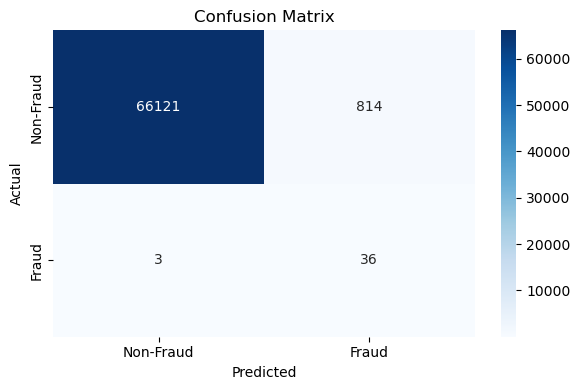

Recall/True Positive Rate: The model got 92.31% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.24% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.22% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [27]:
y_oos_prob = pipeline.pipeline.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

# CV Eval

In [ ]:
pipeline.build_pipeline()
cv_scores = pipeline.cross_validate(X, y, cv=5)
print("CV Scores:", cv_scores)